<a href="https://colab.research.google.com/github/Joss894/EstadisticaVeran2026/blob/main/StudentPerformance%5CStudent_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/Joss894/EstadisticaVeran2026/refs/heads/main/StudentPerformance/Student_Performance.csv")

df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers _Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


1.**Establesca una variable dependiente ( Y ) y una variable independiente ( X ).**

**Y :** Indice de rendimiento porque depende de las horas de estudio que tengas por dia.

**X** : Son las horas de estudio porque depende cuantas horas estudies al dia es tu capacidad de rendimiento

In [13]:
# Y: Performance_Index
# X: Hours_Studied

X = df["Hours_Studied"]   #Variable independiente
Y = df["Performance_Index"] #Variable dependiente

2.**Realice un diagrama de dispersión para estos datos.**

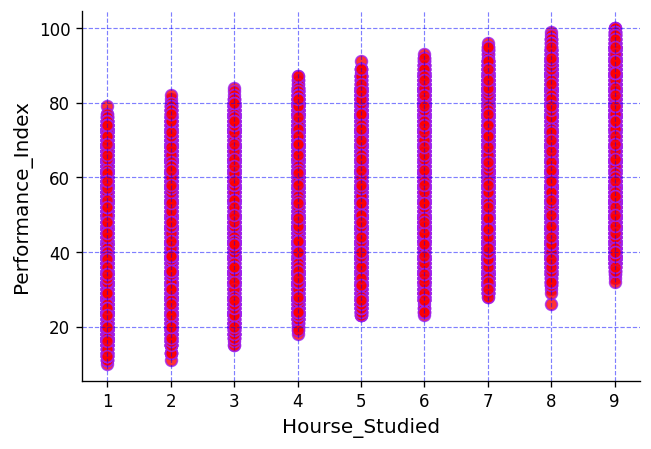

In [14]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hourse_Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance_Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)



3.**¿Los datos soportan la suposición de linealidad?**

Si tiene linealidad porque al aumentar las horas de estudio, la calificacion aumenta.


4.**Calcule el coeficiente de correlación e interprete el resultado.**

In [15]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.3737
valor_p:  0.0000


El coeficiente de correlacion es **r=−0.3737** , este valor indica que la correlacion es moderada, cuando una variable aumenta la otra tiende aumentar tambien.

5.**Calcule el coeficiente de determinación e interprete el resultado.**

In [16]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)


In [17]:
# Coeficiente de determinacion
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinacion: {r2: 0.2%}")

Coeficiente de determinacion:  13.97%


Con coeficiente de determinacion  $$r^2=13.97%$$ indica que la relacion entre las variables es baja, ya que existen mas factores que influyen.

6.**Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.**

In [18]:
modelo.params

,0
const,41.379175
Hours_Studied,2.773063


La ecuacion de la recta es:

$$
\hat{y}=41.379175-2.773063X$$

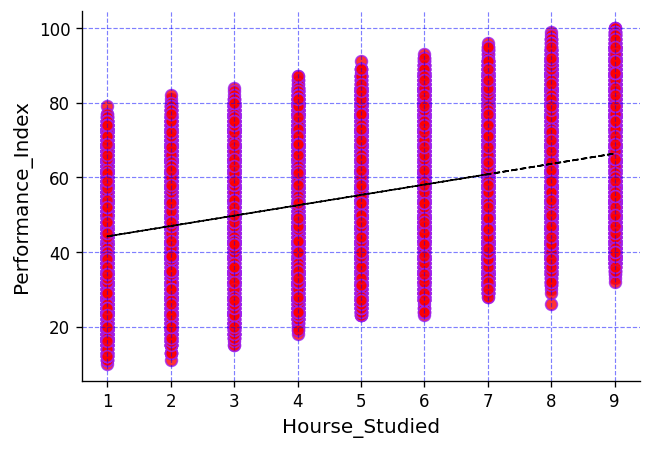

In [19]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada,
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hourse_Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance_Index', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)


7.**Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ( b1 )**

In [20]:
modelo.conf_int(alpha=0.05)

,0,1
const,40.620341,42.138008
Hours_Studied,2.638143,2.907983


8.**Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [21]:
residuales = modelo.resid

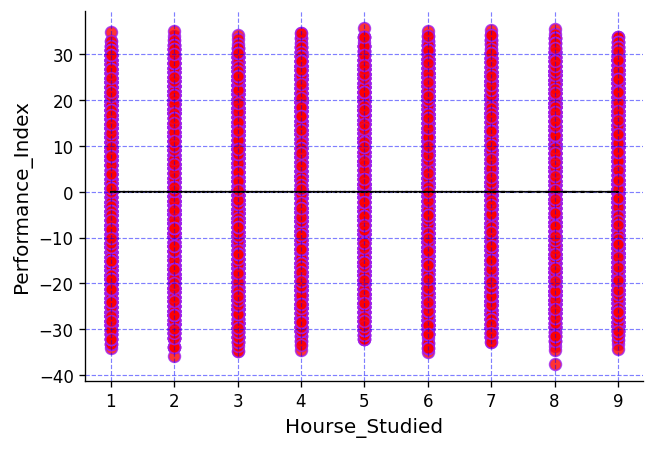

In [22]:
# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X,residuales,      # <---------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada * 0,# <---------------------------------------------------------
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hourse_Studied', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Performance_Index', # etiqueta del eje y #<-----------------------------------------
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)


9.**Realice la prueba de Shapiro para los residuales y comente el resultado.**

valor-p (Shapiro) = 2.3269507843403982e-45


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


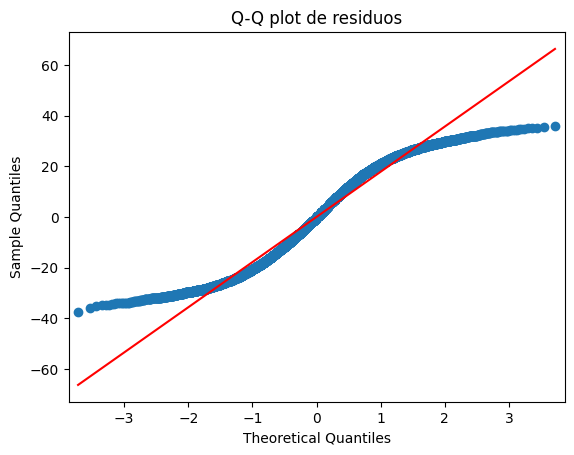

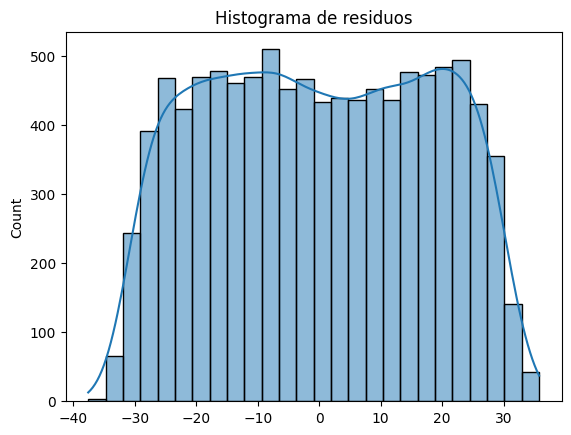

In [23]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk

#test de shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()


10.**Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [24]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')


valor-p de Breusch-Pagan:  0.9742



In [26]:
df.describe()

,Hours_Studied,Previous_Scores,Sleep_Hours,Sample_Question_Papers _Practiced,Performance_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [28]:
# miniimo Hourse_Studied: 1
# maximo  Hourse_Studied: 9

#interpolar, valor de x entre 1 y 9

#interpolar 1
y_25 = modelo.predict([1, 25])
y_32 = modelo.predict([1, 32])

print(f"Para X = 7, Y = {Y_7[0] : 0.4f}")
print(f"Para X = 4, Y = {Y_4[0] : 0.4f}")
df

NameError: name 'Y_7' is not defined